Данные: датасет подержанных автомобилей (used_cars.csv)

Задача: **регрессия** — предсказание цены автомобиля (`price`)

## Разведочный анализ, заполнение пропусков, преобразование категориальных признаков

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('used_cars.csv')
data.head(10)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"
5,Acura,ILX 2.4L,2016,"136,397 mi.",Gasoline,2.4 Liter,F,Silver,Ebony.,None reported,NaN,"$14,798"
6,Audi,S3 2.0T Premium Plus,2017,"84,000 mi.",Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,"$31,000"
7,BMW,740 iL,2001,"242,000 mi.",Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes,"$7,300"
8,Lexus,RC 350 F Sport,2021,"23,436 mi.",Gasoline,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Black,None reported,Yes,"$41,927"
9,Tesla,Model X Long Range Plus,2020,"34,000 mi.",NaN,534.0HP Electric Motor Electric Fuel System,A/T,Black,Black,None reported,Yes,"$69,950"


In [3]:
data.dtypes

brand             str
model             str
model_year      int64
milage            str
fuel_type         str
engine            str
transmission      str
ext_col           str
int_col           str
accident          str
clean_title       str
price             str
dtype: object

In [4]:
data.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [5]:
# Очистка числовых столбцов от символов
data['price'] = data['price'].str.replace('[$,]', '', regex=True).astype(float)
data['milage'] = data['milage'].str.replace(' mi.', '', regex=False).str.replace(',', '').astype(float)

In [6]:
# Анализ пропусков в числовых столбцах
total_count = data.shape[0]
num_cols = []
for col in data.columns:
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count > 0 and (dt == 'float64' or dt == 'int64'):
        num_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

In [7]:
# Заполнение пропусков числовых столбцов средним значением
if num_cols:
    data[num_cols] = data[num_cols].fillna(data[num_cols].mean())

In [8]:
# Анализ пропусков в категориальных столбцах
cat_cols = []
for col in data.columns:
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count > 0 and (dt == 'object' or dt == 'str'):
        cat_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка fuel_type. Тип данных str. Количество пустых значений 170, 4.24%.
Колонка accident. Тип данных str. Количество пустых значений 113, 2.82%.
Колонка clean_title. Тип данных str. Количество пустых значений 596, 14.87%.


In [9]:
# Заполнение пропусков категориальных столбцов модой
categorical_cols = ['fuel_type', 'accident', 'clean_title']
for col in categorical_cols:
    if col in data.columns:
        mode_val = data[col].mode()[0]
        data[col] = data[col].fillna(mode_val)
        print(f"Столбец '{col}' заполнен значением: {mode_val}")

Столбец 'fuel_type' заполнен значением: Gasoline
Столбец 'accident' заполнен значением: None reported
Столбец 'clean_title' заполнен значением: Yes


In [10]:
data.isnull().sum()

brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64

In [11]:
# Извлечение объёма двигателя (числовое значение) из строки
data['engine_size'] = data['engine'].str.extract(r'(\d+\.?\d*)L').astype(float)
data['engine_size'] = data['engine_size'].fillna(data['engine_size'].mean())
data[['engine', 'engine_size']].head()

,engine,engine_size
0,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,3.700000
1,3.8L V6 24V GDI DOHC,3.800000
2,3.5 Liter DOHC,3.709045
3,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,3.500000
4,2.0L I4 16V GDI DOHC Turbo,2.000000


In [12]:
# Кодирование категориальных признаков
from sklearn.preprocessing import OrdinalEncoder

# One-Hot Encoding для признаков с небольшим числом уникальных значений
data_encoded = pd.get_dummies(
    data,
    columns=['fuel_type', 'accident', 'clean_title'],
    prefix=['fuel', 'accident', 'title']
)

# Удаление столбцов, которые не нужны для обучения
data_encoded = data_encoded.drop(columns=['engine', 'model'])

# OrdinalEncoder для столбцов с большим числом уникальных значений
oe = OrdinalEncoder()
data_encoded[['brand', 'transmission', 'ext_col', 'int_col']] = oe.fit_transform(
    data_encoded[['brand', 'transmission', 'ext_col', 'int_col']]
)

# Переместить целевой признак в конец
col = data_encoded.pop('price')
data_encoded['price'] = col

data_encoded.head()

,brand,model_year,milage,transmission,ext_col,int_col,engine_size,fuel_Diesel,fuel_E85 Flex Fuel,fuel_Gasoline,fuel_Hybrid,fuel_Plug-In Hybrid,fuel_not supported,fuel_–,accident_At least 1 accident or damage reported,accident_None reported,title_Yes,price
0,14.0,2013,51000.0,16.0,29.0,14.0,3.700000,False,True,False,False,False,False,False,True,False,True,10300.0
1,19.0,2021,34742.0,32.0,185.0,71.0,3.800000,False,False,True,False,False,False,False,True,False,True,38005.0
2,27.0,2022,22372.0,40.0,38.0,14.0,3.709045,False,False,True,False,False,False,False,False,True,True,54598.0
3,20.0,2015,88900.0,23.0,29.0,14.0,3.500000,False,False,False,True,False,False,False,False,True,True,15500.0
4,3.0,2021,9835.0,32.0,120.0,14.0,2.000000,False,False,True,False,False,False,False,False,True,True,34999.0


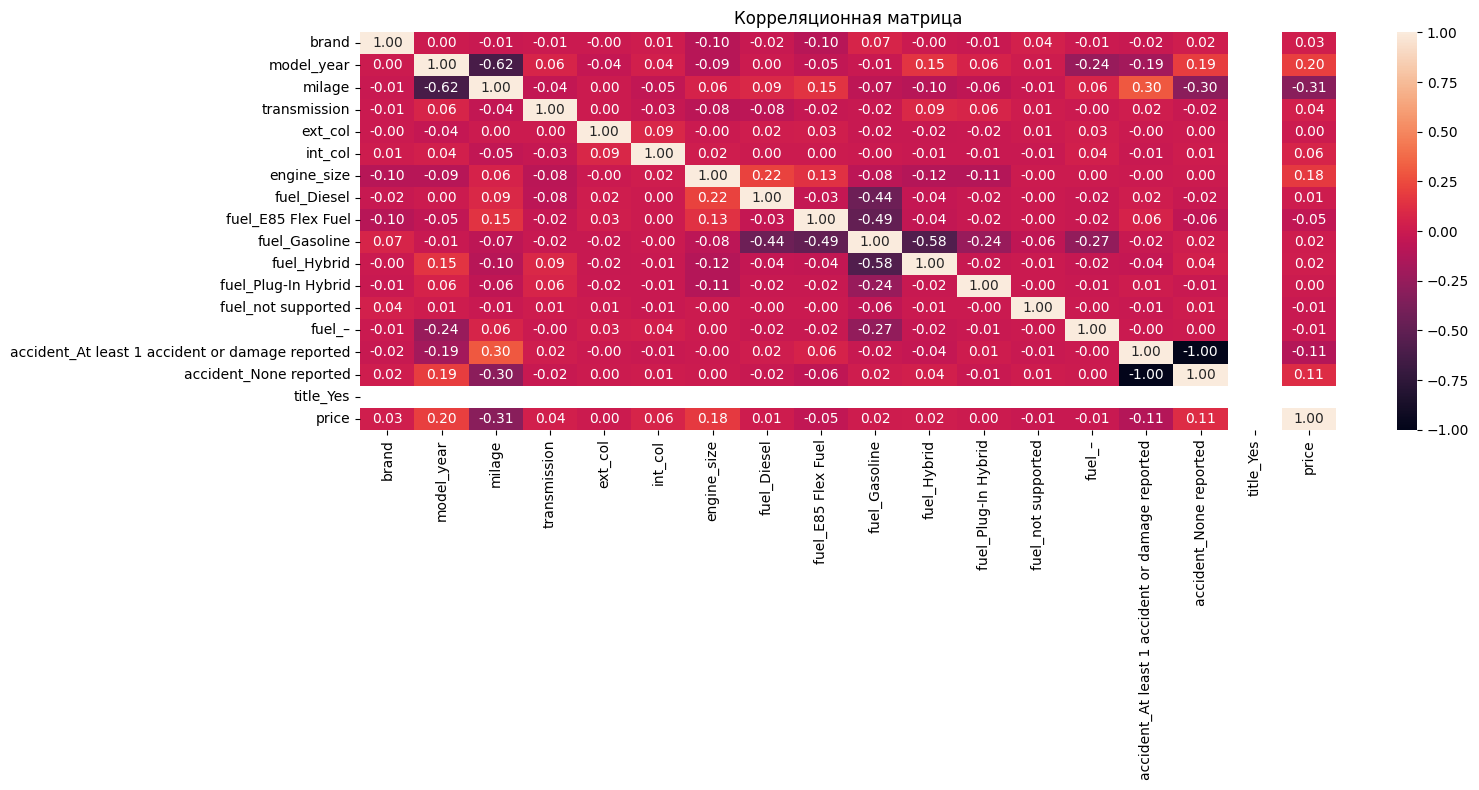

In [13]:
fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(data_encoded.corr(method='pearson'), ax=ax, annot=True, fmt='.2f')
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

In [14]:
X = data_encoded.drop(columns=['price'])
y = data_encoded['price']

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Линейная регрессия

In [16]:
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train_scaled, y_train)
y_pred_lin = lin_reg_model.predict(X_test_scaled)

print(f"MAE:  {mean_absolute_error(y_test, y_pred_lin):.2f}")
print(f"R²:   {r2_score(y_test, y_pred_lin):.4f}")

MAE:  29177.04
R²:   0.0542


## Метод опорных векторов (SVR)

In [17]:
svr_model = SVR(kernel='rbf', C=100, epsilon=1000)
svr_model.fit(X_train_scaled, y_train)
y_pred_svr = svr_model.predict(X_test_scaled)

print(f"MAE:  {mean_absolute_error(y_test, y_pred_svr):.2f}")
print(f"R²:   {r2_score(y_test, y_pred_svr):.4f}")

MAE:  27708.03
R²:   -0.0011


## Дерево решений (регрессия)

In [18]:
tree_model = DecisionTreeRegressor(max_depth=7, random_state=42)
tree_model.fit(X_train_scaled, y_train)
y_pred_tree = tree_model.predict(X_test_scaled)

print(f"MAE:  {mean_absolute_error(y_test, y_pred_tree):.2f}")
print(f"R²:   {r2_score(y_test, y_pred_tree):.4f}")

MAE:  24180.74
R²:   0.1047


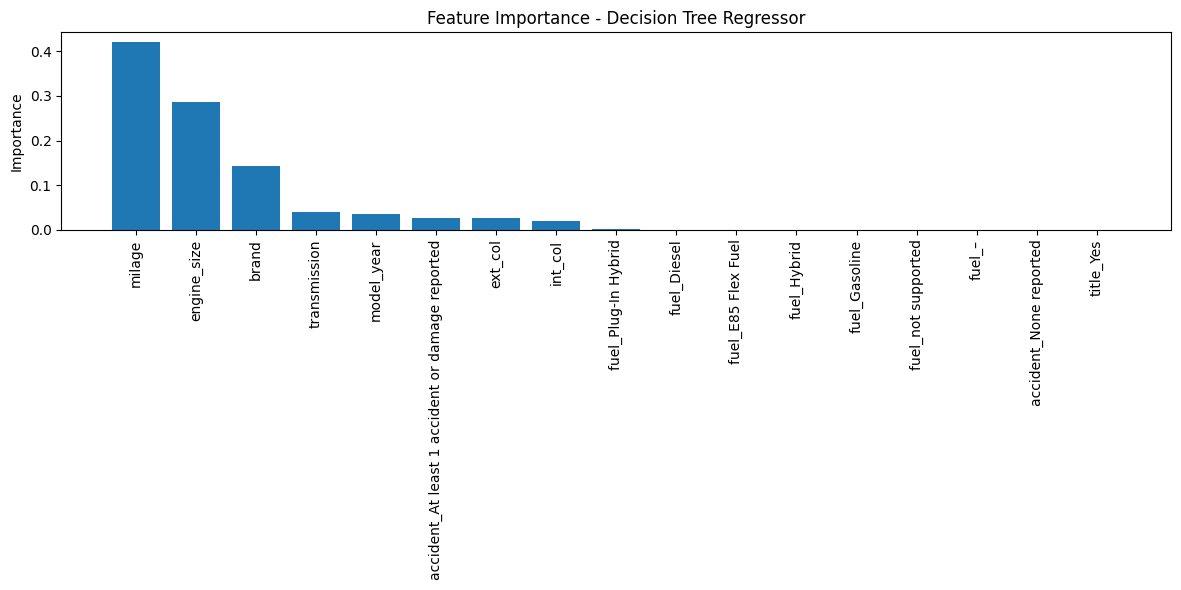

In [19]:
# График важности признаков
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree_model.feature_importances_
})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(feature_importance['Feature'], feature_importance['Importance'])
plt.xticks(rotation=90)
plt.title('Feature Importance - Decision Tree Regressor')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

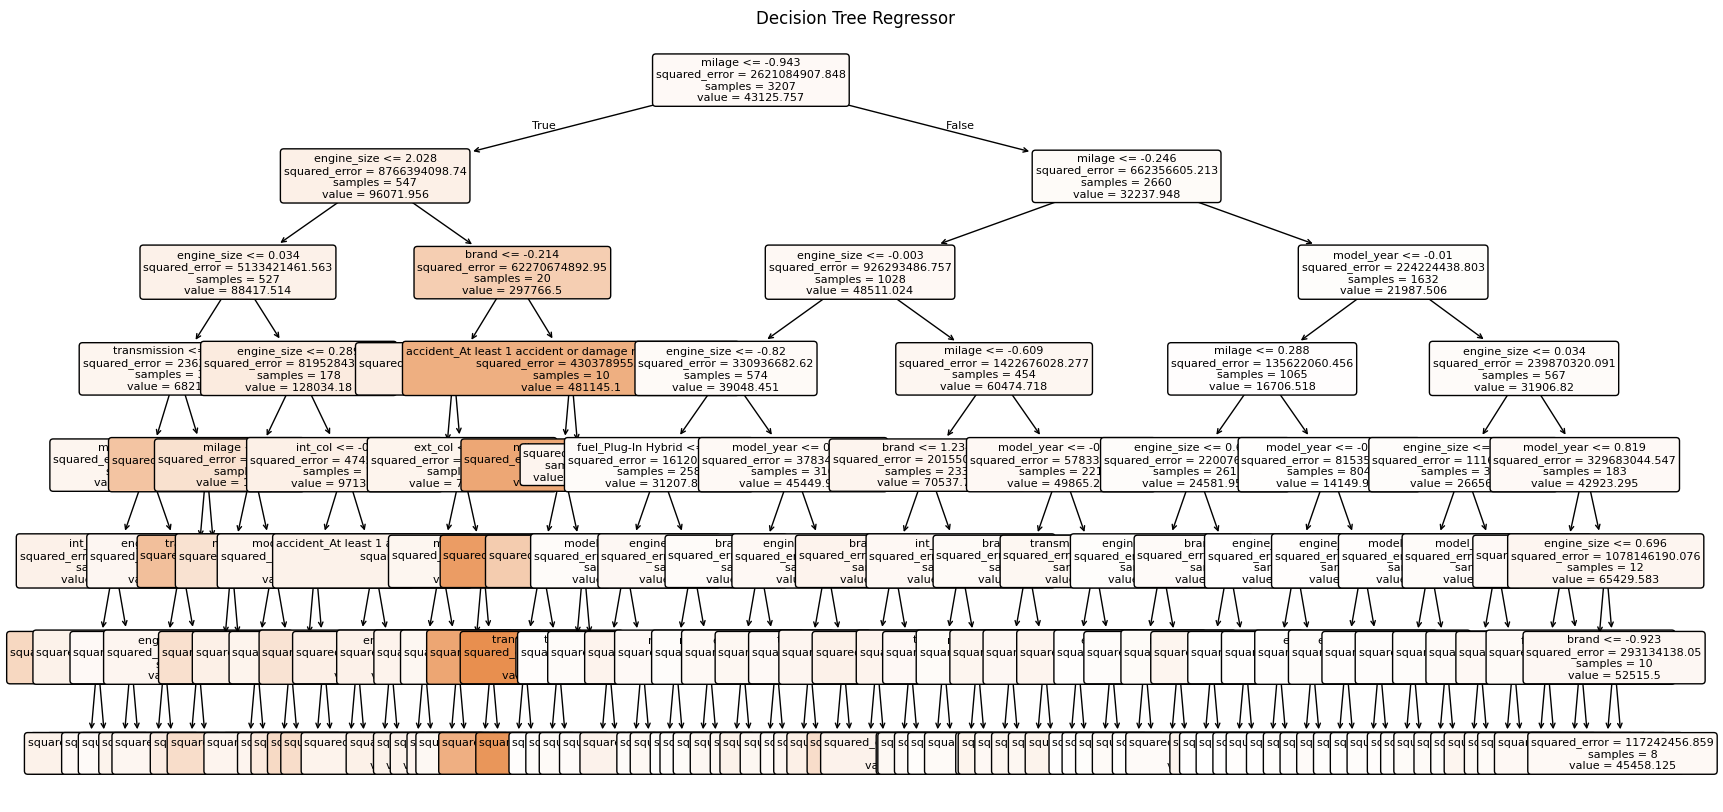

In [20]:
# Визуализация дерева решений
plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('Decision Tree Regressor')
plt.show()

In [21]:
# Правила дерева решений в текстовом виде
tree_rules = export_text(tree_model, feature_names=list(X.columns))
print(tree_rules)

|--- milage <= -0.94
|   |--- engine_size <= 2.03
|   |   |--- engine_size <= 0.03
|   |   |   |--- transmission <= 1.95
|   |   |   |   |--- milage <= -1.17
|   |   |   |   |   |--- int_col <= -0.63
|   |   |   |   |   |   |--- milage <= -1.21
|   |   |   |   |   |   |   |--- value: [299000.00]
|   |   |   |   |   |   |--- milage >  -1.21
|   |   |   |   |   |   |   |--- value: [179900.00]
|   |   |   |   |   |--- int_col >  -0.63
|   |   |   |   |   |   |--- ext_col <= 1.40
|   |   |   |   |   |   |   |--- value: [85322.00]
|   |   |   |   |   |   |--- ext_col >  1.40
|   |   |   |   |   |   |   |--- value: [238900.00]
|   |   |   |   |--- milage >  -1.17
|   |   |   |   |   |--- engine_size <= -0.82
|   |   |   |   |   |   |--- milage <= -1.03
|   |   |   |   |   |   |   |--- value: [45380.76]
|   |   |   |   |   |   |--- milage >  -1.03
|   |   |   |   |   |   |   |--- value: [35628.92]
|   |   |   |   |   |--- engine_size >  -0.82
|   |   |   |   |   |   |--- engine_size <= -0.45


## Сравнение моделей и выводы

               Model           MAE        R²
0  Linear Regression  29177.037243  0.054221
1                SVR  27708.030580 -0.001070
2      Decision Tree  24180.743353  0.104739


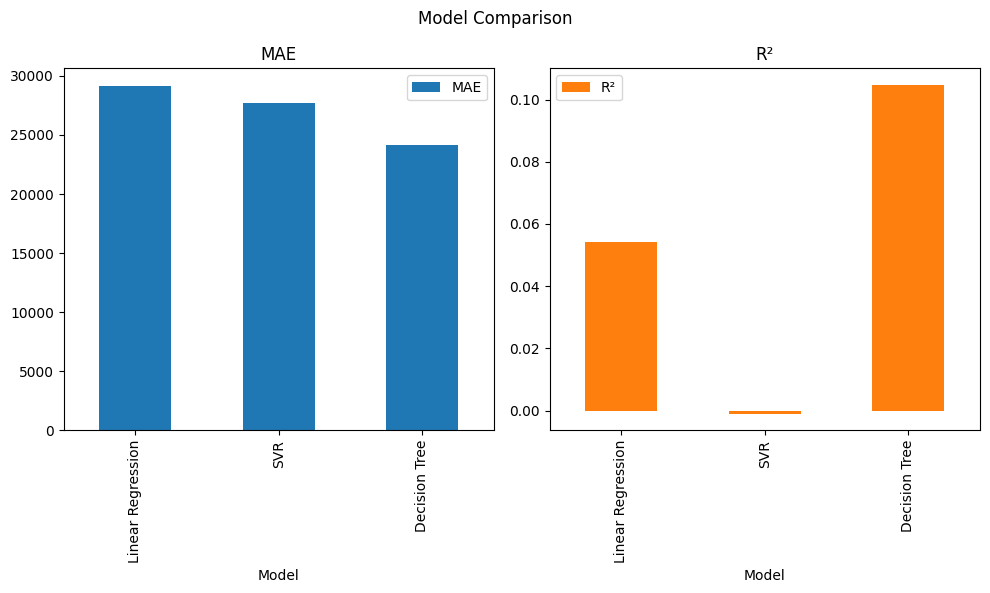

In [22]:
results = [
    {
        'Model': 'Linear Regression',
        'MAE': mean_absolute_error(y_test, y_pred_lin),
        'R²': r2_score(y_test, y_pred_lin)
    },
    {
        'Model': 'SVR',
        'MAE': mean_absolute_error(y_test, y_pred_svr),
        'R²': r2_score(y_test, y_pred_svr)
    },
    {
        'Model': 'Decision Tree',
        'MAE': mean_absolute_error(y_test, y_pred_tree),
        'R²': r2_score(y_test, y_pred_tree)
    }
]

results_df = pd.DataFrame(results)
print(results_df)

results_df.set_index('Model')[['MAE', 'R²']].plot(kind='bar', figsize=(10, 6), subplots=True, layout=(1, 2))
plt.suptitle('Model Comparison')
plt.tight_layout()
plt.show()